
## GitHub Repository
Full project available at:
https://github.com/aradhana5409/Advance_Machine_Learning_Project


# Sleep Apnea Detection using Log-Mel Spectrograms

This notebook trains multiple deep learning models to classify apnea and non-apnea segments using extracted log-Mel spectrogram features.


MOUNTING


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Loading

Preprocessed spectrogram features (X) and labels (y) are loaded for model training and evaluation.

In [ ]:
import os, glob, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras import layers, models, Model
from tensorflow.keras.applications import VGG16

from sklearn.metrics import (
    roc_auc_score,
    confusion_matrix,
    classification_report,
    f1_score,
    roc_curve
)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

DATA_DIR = "/content/drive/MyDrive/PSG_AUDIO_PROJECT/processed_mel_v3"

FINDING SUBJECTS

In [ ]:
x_files = sorted(glob.glob(os.path.join(DATA_DIR, "*_Xmel.npy")))
subjects = np.array(sorted([os.path.basename(f).replace("_Xmel.npy", "") for f in x_files]))

print("Subjects found:", len(subjects))
print(subjects[:10], "..." if len(subjects) > 10 else "")

Subjects found: 71
['00000995-100507' '00000999-100507' '00001000-100507' '00001006-100507'
 '00001008-100507' '00001024-100507' '00001028-100507' '00001037-100507'
 '00001039-100507' '00001041-100507'] ...


## Train-Test Split

The dataset is split into training and testing sets to evaluate model generalization.

In [ ]:
subjects_shuffled = subjects.copy()
np.random.shuffle(subjects_shuffled)

split = int(0.8 * len(subjects_shuffled))
train_subjects = subjects_shuffled[:split].tolist()
test_subjects = subjects_shuffled[split:].tolist()

print("Train subjects:", len(train_subjects))
print("Test subjects :", len(test_subjects))

Train subjects: 56
Test subjects : 15


INFO

In [ ]:
total_normal = 0
total_apnea = 0
rows = []

for sid in subjects:
    y = np.load(os.path.join(DATA_DIR, f"{sid}_y.npy"))
    n0 = int((y == 0).sum())
    n1 = int((y == 1).sum())
    total_normal += n0
    total_apnea += n1
    rows.append([sid, len(y), n0, n1])

dist_df = pd.DataFrame(rows, columns=["subject", "total_windows", "normal", "apnea"])
dist_df.head()

,subject,total_windows,normal,apnea
0,00000995-100507,2138,1959,179
1,00000999-100507,2260,1777,483
2,00001000-100507,2160,1741,419
3,00001006-100507,2863,2079,784
4,00001008-100507,2307,2000,307


CLASS DISTRIBUTION

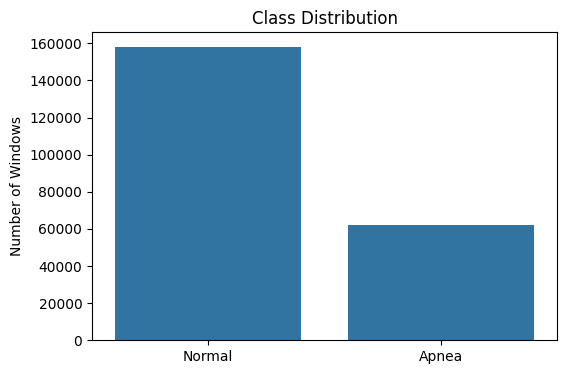

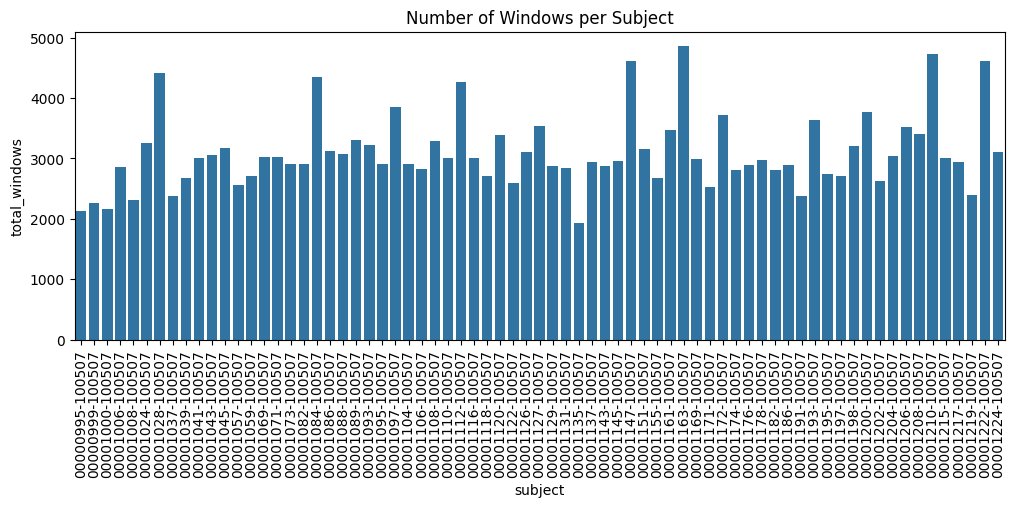

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x=["Normal", "Apnea"], y=[total_normal, total_apnea])
plt.title("Class Distribution")
plt.ylabel("Number of Windows")
plt.show()

plt.figure(figsize=(12,4))
sns.barplot(data=dist_df, x="subject", y="total_windows")
plt.xticks(rotation=90)
plt.title("Number of Windows per Subject")
plt.show()

VISUALISING LOG-MEL SPECTROGRAMS

Subject: 00000995-100507
X shape: (2138, 64, 314)
y shape: (2138,)
Normal windows: 1959
Apnea windows: 179


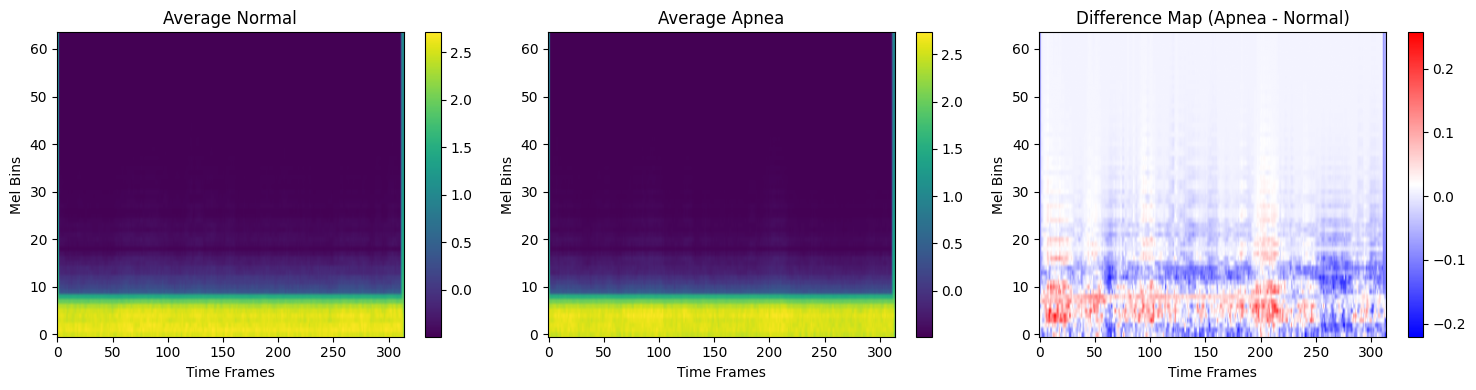

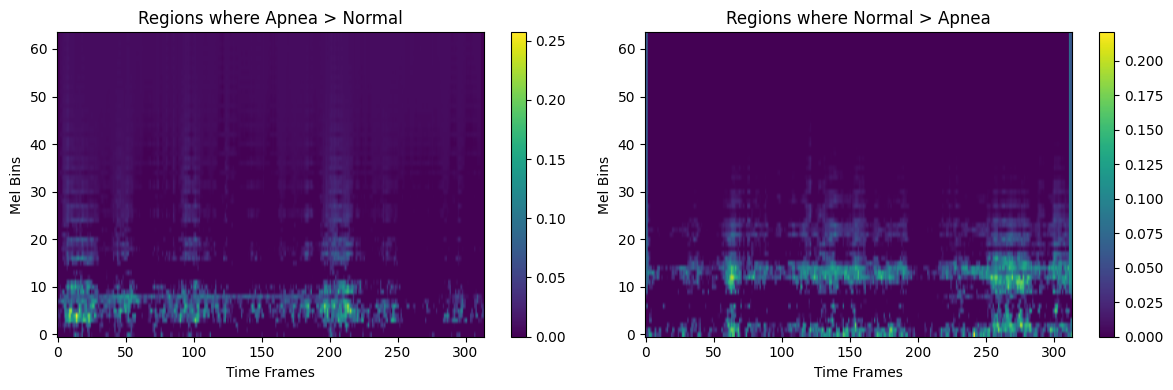

In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt

#PATH
DATA_DIR = "/content/drive/MyDrive/PSG_AUDIO_PROJECT/processed_mel_v3"

#LOAD ONE SUBJECT
sid = "00000995-100507"   # change this if you want another subject

x_path = os.path.join(DATA_DIR, f"{sid}_Xmel.npy")
y_path = os.path.join(DATA_DIR, f"{sid}_y.npy")

X = np.load(x_path)
y = np.load(y_path)

print("Subject:", sid)
print("X shape:", X.shape)
print("y shape:", y.shape)

# FIND NORMAL / APNEA INDICES
normal_idx = np.where(y == 0)[0]
apnea_idx = np.where(y == 1)[0]

print("Normal windows:", len(normal_idx))
print("Apnea windows:", len(apnea_idx))

# take a small number for quick visualization
take_n = min(20, len(normal_idx))
take_a = min(20, len(apnea_idx))

normal_specs = X[normal_idx[:take_n]]
apnea_specs = X[apnea_idx[:take_a]]

# AVERAGE SPECTROGRAMS
avg_normal = np.mean(normal_specs, axis=0)
avg_apnea = np.mean(apnea_specs, axis=0)

#DIFFERENCE MAP
diff_map = avg_apnea - avg_normal

# separate positive and negative parts
apnea_stronger = np.clip(diff_map, 0, None)     # where apnea > normal
normal_stronger = np.clip(-diff_map, 0, None)   # where normal > apnea

# PLOT 1: AVERAGE NORMAL / APNEA / DIFFERENCE
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.imshow(avg_normal, aspect="auto", origin="lower")
plt.title("Average Normal")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(avg_apnea, aspect="auto", origin="lower")
plt.title("Average Apnea")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(diff_map, aspect="auto", origin="lower", cmap="bwr")
plt.title("Difference Map (Apnea - Normal)")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar()

plt.tight_layout()
plt.show()

#PLOT 2: SPLIT DIFFERENCE MAPS
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(apnea_stronger, aspect="auto", origin="lower")
plt.title("Regions where Apnea > Normal")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(normal_stronger, aspect="auto", origin="lower")
plt.title("Regions where Normal > Apnea")
plt.xlabel("Time Frames")
plt.ylabel("Mel Bins")
plt.colorbar()

plt.tight_layout()
plt.show()

DATA GENERATION

In [ ]:
class MelSequence(tf.keras.utils.Sequence):
    def __init__(self, subject_list, data_dir, batch_size=32, shuffle=True):
        self.subject_list = subject_list
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.shuffle = shuffle

        self.index = []
        self.X_cache = {}
        self.y_cache = {}

        for sid in self.subject_list:
            y = np.load(os.path.join(self.data_dir, f"{sid}_y.npy"), mmap_mode="r")
            self.index.extend([(sid, i) for i in range(len(y))])

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.index) / self.batch_size))

    def __getitem__(self, idx):
        batch_items = self.index[idx * self.batch_size:(idx + 1) * self.batch_size]

        Xb, yb = [], []

        for sid, i in batch_items:
            if sid not in self.X_cache:
                self.X_cache[sid] = np.load(
                    os.path.join(self.data_dir, f"{sid}_Xmel.npy"),
                    mmap_mode="r"
                )
                self.y_cache[sid] = np.load(
                    os.path.join(self.data_dir, f"{sid}_y.npy"),
                    mmap_mode="r"
                )

            x = np.array(self.X_cache[sid][i], dtype=np.float32)
            y = int(self.y_cache[sid][i])

            x = (x - x.mean()) / (x.std() + 1e-6)
            x = x[..., None]

            Xb.append(x)
            yb.append(y)

        return np.stack(Xb).astype(np.float32), np.array(yb, dtype=np.int32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.index)

BATCH GENERATION

In [ ]:
train_seq = MelSequence(train_subjects, DATA_DIR, batch_size=32, shuffle=True)
test_seq  = MelSequence(test_subjects, DATA_DIR, batch_size=32, shuffle=False)

sample_x, sample_y = train_seq[0]
input_shape = sample_x.shape[1:]

print("Train batches:", len(train_seq))
print("Test batches :", len(test_seq))
print("Input shape  :", input_shape)

Train batches: 5447
Test batches : 1426
Input shape  : (64, 314, 1)


## CNN Model

A baseline Convolutional Neural Network is used to learn spatial patterns from spectrogram inputs.

In [ ]:
def build_cnn(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(64, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(128, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(256, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.GlobalAveragePooling2D(),

        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(1, activation="sigmoid")
    ])
    return model

tf.keras.backend.clear_session()
cnn_model = build_cnn(input_shape)
cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 314, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 314, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 157, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 157, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 157, 64)    │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 78, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 78, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 78, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 39, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 39, 256)     │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 8, 39, 256)     │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 455,809 (1.74 MB)

 Trainable params: 454,849 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

TRAINING

In [ ]:
cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True
)

cnn_history = cnn_model.fit(
    train_seq,
    validation_data=test_seq,
    epochs=8,
    steps_per_epoch=min(400, len(train_seq)),
    validation_steps=min(100, len(test_seq)),
    class_weight={0:1, 1:3},
    callbacks=[cb],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 250s 550ms/step - auc: 0.5746 - loss: 1.0645 - val_auc: 0.5748 - val_loss: 0.9821
Epoch 2/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 58s 146ms/step - auc: 0.6006 - loss: 1.0517 - val_auc: 0.6292 - val_loss: 0.7057
Epoch 3/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 48s 121ms/step - auc: 0.6092 - loss: 1.0459 - val_auc: 0.6245 - val_loss: 0.7220
Epoch 4/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 42s 105ms/step - auc: 0.6287 - loss: 1.0285 - val_auc: 0.6225 - val_loss: 0.7313
Epoch 5/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 41s 103ms/step - auc: 0.6319 - loss: 1.0332 - val_auc: 0.6250 - val_loss: 0.6763


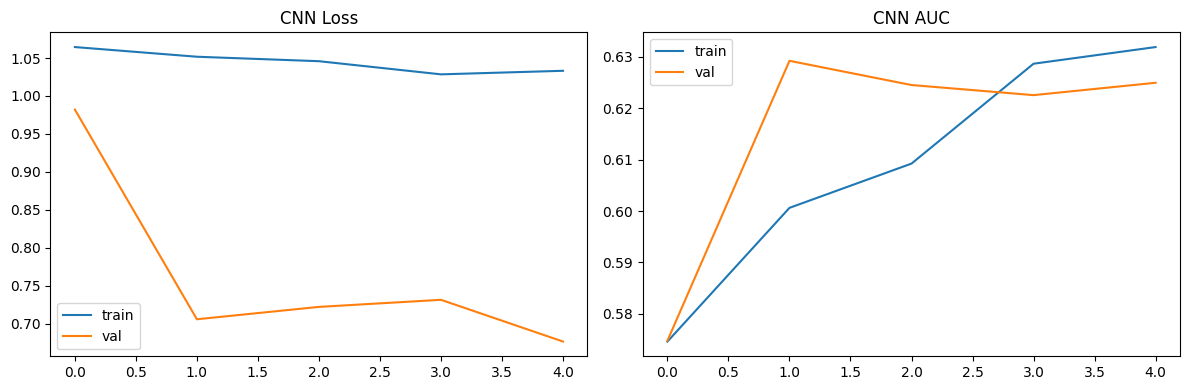

In [ ]:
plot_history(cnn_history, "CNN")

# CNN RESULTS

CNN AUC: 0.6077246403303858
CNN Best Threshold: 0.55
CNN Best F1: 0.47502987877753117
              precision    recall  f1-score   support

           0      0.849     0.302     0.445     32724
           1      0.328     0.864     0.475     12883

    accuracy                          0.461     45607
   macro avg      0.588     0.583     0.460     45607
weighted avg      0.702     0.461     0.454     45607



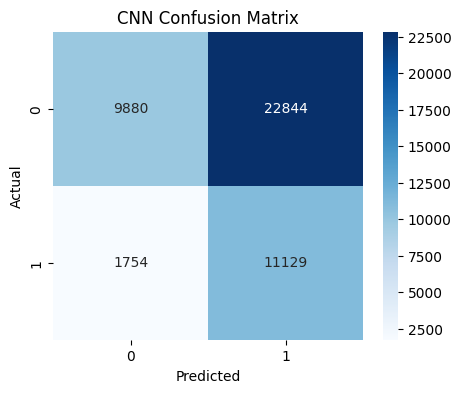

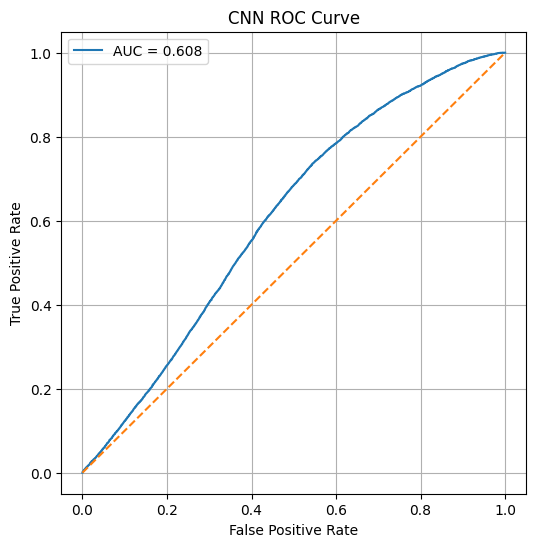

In [ ]:
cnn_results = evaluate_model(cnn_model, test_seq)

print("CNN AUC:", cnn_results["auc"])
print("CNN Best Threshold:", cnn_results["best_thr"])
print("CNN Best F1:", cnn_results["best_f1"])
print(cnn_results["report"])

plot_cm(cnn_results["cm"], "CNN Confusion Matrix")
plot_roc(cnn_results["y_true"], cnn_results["y_prob"], "CNN ROC Curve")

## Advanced Models

Pretrained and hybrid architectures are used to improve performance by capturing complex patterns in the data.

# CNN + TRANSFORMER MODEL

In [ ]:
def transformer_block(x, num_heads=4, key_dim=32, ff_dim=128, dropout=0.1):
    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=key_dim,
        dropout=dropout
    )(x, x)
    x = layers.LayerNormalization(epsilon=1e-6)(x + attn)

    ff = layers.Dense(ff_dim, activation="relu")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(x.shape[-1])(ff)

    x = layers.LayerNormalization(epsilon=1e-6)(x + ff)
    return x

def build_cnn_transformer(input_shape):
    inp = layers.Input(shape=input_shape)

    x = layers.Conv2D(32, (3,3), padding="same", activation="relu")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(64, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.Conv2D(128, (3,3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    h, w, c = x.shape[1], x.shape[2], x.shape[3]
    x = layers.Reshape((h * w, c))(x)

    x = transformer_block(x)
    x = transformer_block(x)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    return Model(inputs=inp, outputs=out)

tf.keras.backend.clear_session()
trans_model = build_cnn_transformer(input_shape)
trans_model.compile(
    optimizer=tf.keras.optimizers.Adam(3e-5),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)
trans_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 314,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 314,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 314,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 157,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 157,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 157,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 78,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 78,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 78,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1248, 128) │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1248, 128) │     66,048 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1248, 128) │          0 │ reshape[0][0],    │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 1248, 128) │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1248, 128) │     16,512 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 1248, 128) │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1248, 128) │     16,512 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 1248, 128) │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 1248, 128) │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                 

 Total params: 309,377 (1.18 MB)

 Trainable params: 308,929 (1.18 MB)

 Non-trainable params: 448 (1.75 KB)

TRAINING

In [ ]:
trans_history = trans_model.fit(
    train_seq,
    validation_data=test_seq,
    epochs=8,
    steps_per_epoch=min(400, len(train_seq)),
    validation_steps=min(100, len(test_seq)),
    class_weight={0:1, 1:3},
    callbacks=[cb],
    verbose=1
)

Epoch 1/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 108s 218ms/step - auc: 0.5481 - loss: 1.0732 - val_auc: 0.6029 - val_loss: 0.7402
Epoch 2/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 94s 236ms/step - auc: 0.5554 - loss: 1.0613 - val_auc: 0.5905 - val_loss: 0.7097
Epoch 3/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 101s 252ms/step - auc: 0.5648 - loss: 1.0621 - val_auc: 0.5912 - val_loss: 0.6827


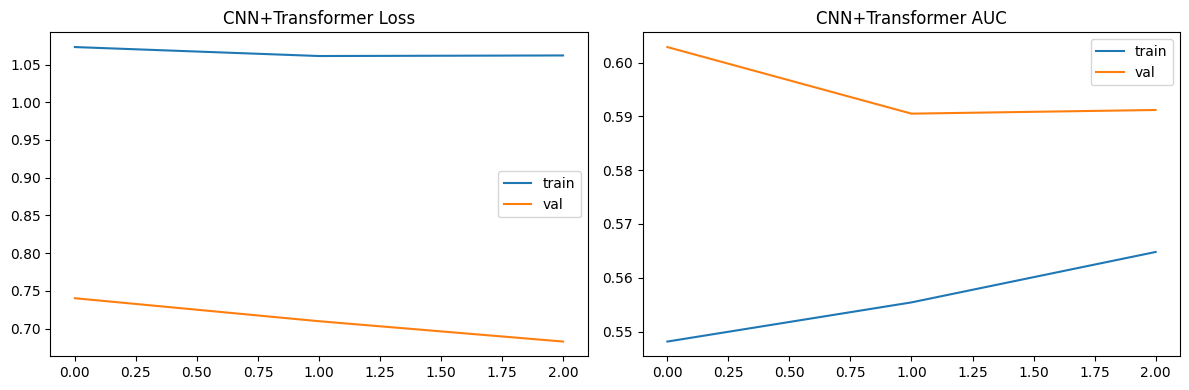

In [ ]:
plot_history(trans_history, "CNN+Transformer")

# CNN + TRANSFORMER RESULTS

Transformer AUC: 0.5904440480055837
Transformer Best Threshold: 0.6000000000000001
Transformer Best F1: 0.4566228893058161
              precision    recall  f1-score   support

           0      0.862     0.137     0.236     32724
           1      0.301     0.945     0.457     12883

    accuracy                          0.365     45607
   macro avg      0.582     0.541     0.346     45607
weighted avg      0.704     0.365     0.298     45607



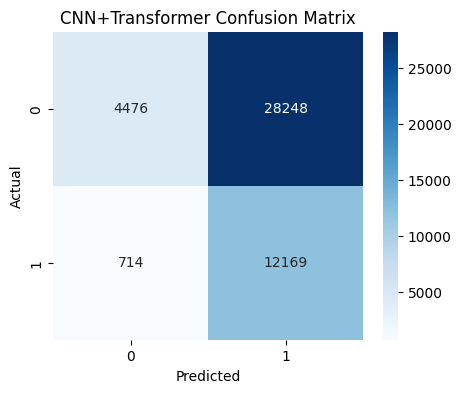

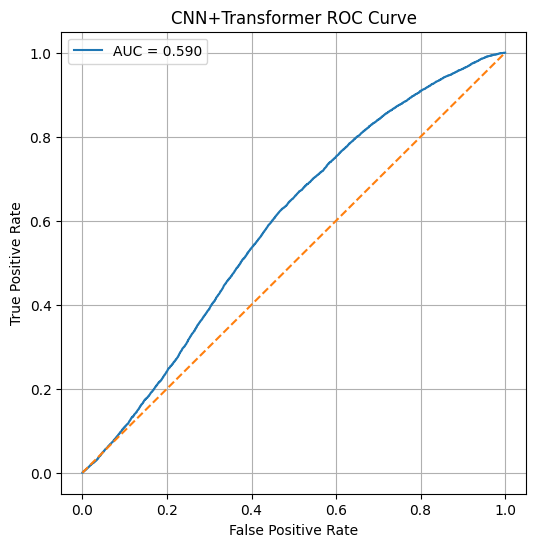

In [ ]:
trans_results = evaluate_model(trans_model, test_seq)

print("Transformer AUC:", trans_results["auc"])
print("Transformer Best Threshold:", trans_results["best_thr"])
print("Transformer Best F1:", trans_results["best_f1"])
print(trans_results["report"])

plot_cm(trans_results["cm"], "CNN+Transformer Confusion Matrix")
plot_roc(trans_results["y_true"], trans_results["y_prob"], "CNN+Transformer ROC Curve")

TRANSFER LEARNING
# PRETRAINED VGG16 MODEL

In [ ]:
class VGGMelSequence(tf.keras.utils.Sequence):
    def __init__(self, subject_list, data_dir, batch_size=16, shuffle=True, img_size=(128, 128)):
        self.subject_list = subject_list
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.img_size = img_size

        self.index = []
        self.X_cache = {}
        self.y_cache = {}

        for sid in self.subject_list:
            y = np.load(os.path.join(self.data_dir, f"{sid}_y.npy"), mmap_mode="r")
            self.index.extend([(sid, i) for i in range(len(y))])

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.index) / self.batch_size))

    def __getitem__(self, idx):
        batch_items = self.index[idx * self.batch_size:(idx + 1) * self.batch_size]

        Xb, yb = [], []

        for sid, i in batch_items:
            if sid not in self.X_cache:
                self.X_cache[sid] = np.load(
                    os.path.join(self.data_dir, f"{sid}_Xmel.npy"),
                    mmap_mode="r"
                )
                self.y_cache[sid] = np.load(
                    os.path.join(self.data_dir, f"{sid}_y.npy"),
                    mmap_mode="r"
                )

            x = np.array(self.X_cache[sid][i], dtype=np.float32)
            y = int(self.y_cache[sid][i])

            x = (x - x.mean()) / (x.std() + 1e-6)
            x = x[..., None]
            x = tf.image.resize(x, self.img_size).numpy()
            x = np.repeat(x, 3, axis=-1)

            Xb.append(x)
            yb.append(y)

        return np.stack(Xb).astype(np.float32), np.array(yb, dtype=np.int32)

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.index)

vgg_train_seq = VGGMelSequence(train_subjects, DATA_DIR, batch_size=16, shuffle=True)
vgg_test_seq  = VGGMelSequence(test_subjects, DATA_DIR, batch_size=16, shuffle=False)

vgg_sample_x, _ = vgg_train_seq[0]
vgg_input_shape = vgg_sample_x.shape[1:]
print("VGG input shape:", vgg_input_shape)

VGG input shape: (128, 128, 3)


In [ ]:
def build_vgg(input_shape):
    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    for layer in base_model.layers:
        layer.trainable = False

    inp = layers.Input(shape=input_shape)
    x = base_model(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    return Model(inputs=inp, outputs=out)

tf.keras.backend.clear_session()
vgg_model = build_vgg(vgg_input_shape)
vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")]
)
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,481 (56.38 MB)

 Trainable params: 65,793 (257.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
vgg_history = vgg_model.fit(
    vgg_train_seq,
    validation_data=vgg_test_seq,
    epochs=8,
    steps_per_epoch=min(400, len(vgg_train_seq)),
    validation_steps=min(100, len(vgg_test_seq)),
    class_weight={0:1, 1:3},
    callbacks=[cb],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 59s 130ms/step - auc: 0.5019 - loss: 1.1062 - val_auc: 0.5894 - val_loss: 0.6821
Epoch 2/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 50s 125ms/step - auc: 0.5407 - loss: 1.0777 - val_auc: 0.6378 - val_loss: 0.6762
Epoch 3/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 47s 117ms/step - auc: 0.5521 - loss: 1.0726 - val_auc: 0.6342 - val_loss: 0.6777
Epoch 4/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 48s 119ms/step - auc: 0.5632 - loss: 1.0656 - val_auc: 0.6314 - val_loss: 0.6736
Epoch 5/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 45s 114ms/step - auc: 0.5683 - loss: 1.0623 - val_auc: 0.6366 - val_loss: 0.6734


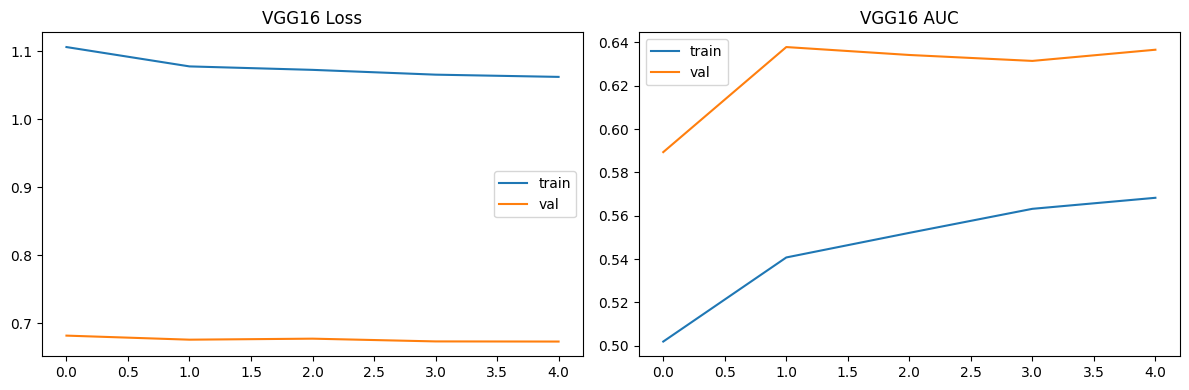

In [ ]:
plot_history(vgg_history, "VGG16")


VGG AUC: 0.5973451065987692
VGG Best Threshold: 0.5
VGG Best F1: 0.4650285156995357
              precision    recall  f1-score   support

           0      0.831     0.287     0.427     32724
           1      0.320     0.851     0.465     12883

    accuracy                          0.447     45607
   macro avg      0.575     0.569     0.446     45607
weighted avg      0.686     0.447     0.438     45607



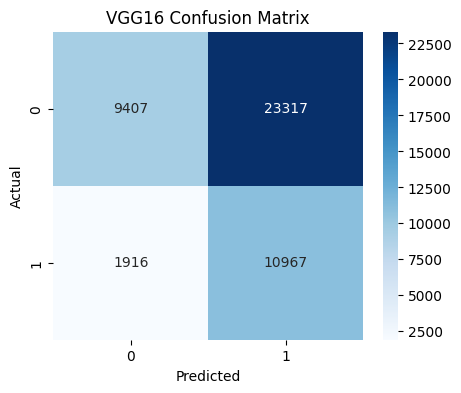

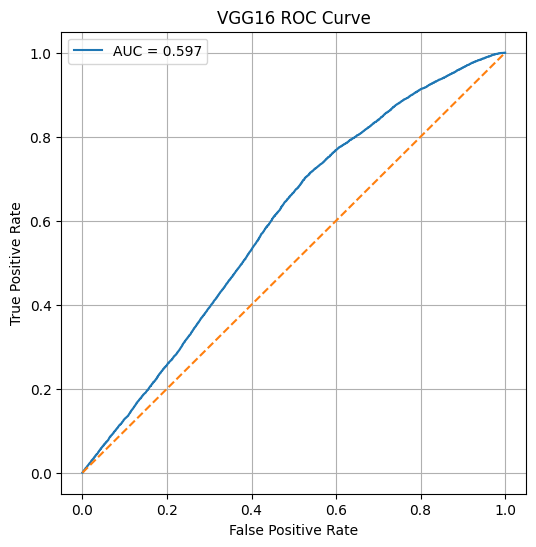

In [ ]:
vgg_results = evaluate_model(vgg_model, vgg_test_seq)

print("VGG AUC:", vgg_results["auc"])
print("VGG Best Threshold:", vgg_results["best_thr"])
print("VGG Best F1:", vgg_results["best_f1"])
print(vgg_results["report"])

plot_cm(vgg_results["cm"], "VGG16 Confusion Matrix")
plot_roc(vgg_results["y_true"], vgg_results["y_prob"], "VGG16 ROC Curve")

SPECTROGRAM IMAGE DATA GENERATOR(KERAS SEQUENCE)

In [ ]:
# this generator is for image-based pretrained models
# it resizes mel spectrograms and makes 3 channels

class SpectrogramImageSequence(tf.keras.utils.Sequence):
    def __init__(self, subject_list, data_dir, batch_size=16, shuffle=True, img_size=(224, 224)):
        self.subject_list = subject_list
        self.data_dir = data_dir
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.img_size = img_size

        self.index = []
        self.X_cache = {}
        self.y_cache = {}

        for sid in self.subject_list:
            y = np.load(os.path.join(self.data_dir, f"{sid}_y.npy"), mmap_mode="r")
            self.index.extend([(sid, i) for i in range(len(y))])

        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.index) / self.batch_size))

    def __getitem__(self, idx):
        batch_items = self.index[idx * self.batch_size:(idx + 1) * self.batch_size]
        Xb, yb = [], []

        for sid, i in batch_items:
            if sid not in self.X_cache:
                self.X_cache[sid] = np.load(
                    os.path.join(self.data_dir, f"{sid}_Xmel.npy"),
                    mmap_mode="r"
                )
                self.y_cache[sid] = np.load(
                    os.path.join(self.data_dir, f"{sid}_y.npy"),
                    mmap_mode="r"
                )

            x = np.array(self.X_cache[sid][i], dtype=np.float32)
            y = int(self.y_cache[sid][i])

            # simple normalisation
            x = (x - x.mean()) / (x.std() + 1e-6)

            # add channel
            x = x[..., None]

            # resize
            x = tf.image.resize(x, self.img_size).numpy()

            # convert 1 channel to 3 channels for pretrained models
            x = np.repeat(x, 3, axis=-1)

            Xb.append(x)
            yb.append(y)

        return np.stack(Xb).astype(np.float32), np.array(yb, dtype=np.int32)

    def on_epoch_end(self):
        if self.shuffle:
            rng = np.random.default_rng(SEED)
            rng.shuffle(self.index)

In [ ]:
img_train_seq = SpectrogramImageSequence(train_subjects, DATA_DIR, batch_size=16, shuffle=True, img_size=(224, 224))
img_test_seq  = SpectrogramImageSequence(test_subjects, DATA_DIR, batch_size=16, shuffle=False, img_size=(224, 224))

img_sample_x, _ = img_train_seq[0]
img_input_shape = img_sample_x.shape[1:]

print("image input shape:", img_input_shape)

image input shape: (224, 224, 3)


# EFFICIENTNETB0 MODEL

In [ ]:
from tensorflow.keras.applications import EfficientNetB0

# this model is stronger than vgg and usually more stable
def build_efficientnet(input_shape):
    base_model = EfficientNetB0(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # first keep pretrained layers frozen
    for layer in base_model.layers:
        layer.trainable = False

    inputs = layers.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )
    return model

TRAINING

In [ ]:
tf.keras.backend.clear_session()

eff_model = build_efficientnet(img_input_shape)
eff_model.summary()

eff_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True
)

eff_history = eff_model.fit(
    img_train_seq,
    validation_data=img_test_seq,
    epochs=8,
    steps_per_epoch=min(400, len(img_train_seq)),
    validation_steps=min(100, len(img_test_seq)),
    class_weight={0:1, 1:1.5},   # kept smaller to reduce overprediction of apnea
    callbacks=[eff_cb],
    verbose=1
)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 89s 148ms/step - auc: 0.5064 - loss: 0.7621 - val_auc: 0.5000 - val_loss: 0.7382
Epoch 2/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 49s 122ms/step - auc: 0.5022 - loss: 0.7586 - val_auc: 0.5000 - val_loss: 0.7419
Epoch 3/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 49s 122ms/step - auc: 0.4872 - loss: 0.7603 - val_auc: 0.4989 - val_loss: 0.7699
Epoch 4/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 46s 115ms/step - auc: 0.4988 - loss: 0.7562 - val_auc: 0.5000 - val_loss: 0.7719


EFFICIENTNETB0 RESULTS

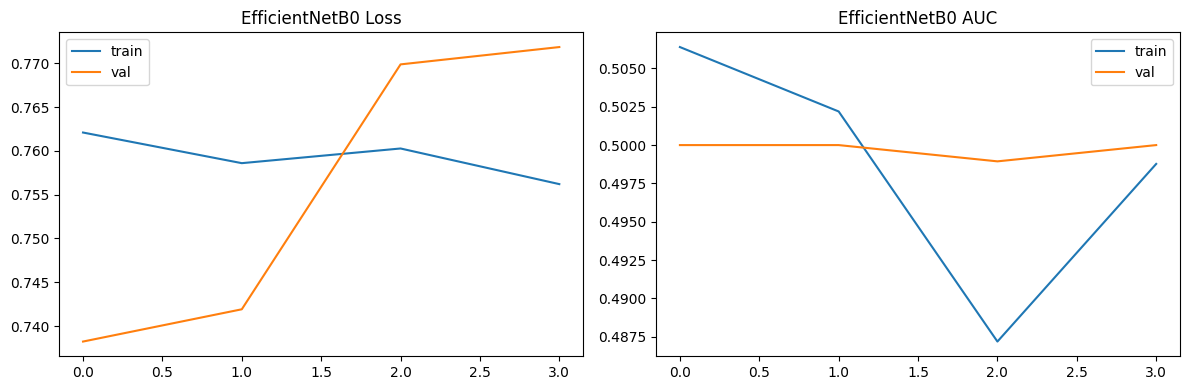

EfficientNet AUC: 0.5071096674296096
EfficientNet Best Threshold: 0.05
EfficientNet Best F1: 0.4405197469652932
              precision    recall  f1-score   support

           0      0.000     0.000     0.000     32724
           1      0.282     1.000     0.441     12883

    accuracy                          0.282     45607
   macro avg      0.141     0.500     0.220     45607
weighted avg      0.080     0.282     0.124     45607



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


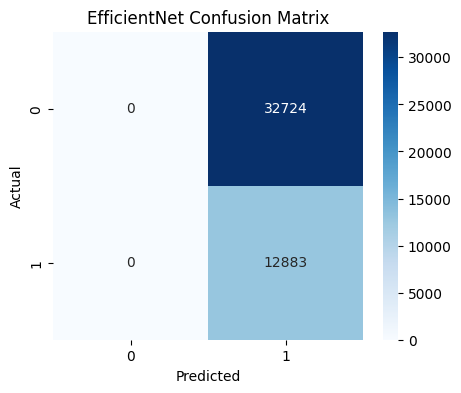

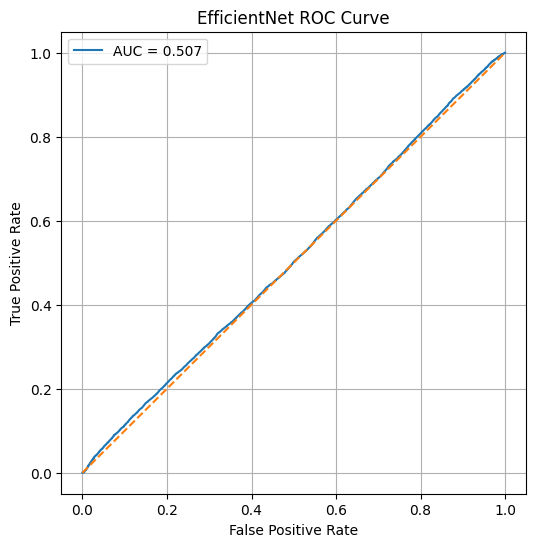

In [ ]:
plot_history(eff_history, "EfficientNetB0")

eff_results = evaluate_model(eff_model, img_test_seq)

print("EfficientNet AUC:", eff_results["auc"])
print("EfficientNet Best Threshold:", eff_results["best_thr"])
print("EfficientNet Best F1:", eff_results["best_f1"])
print(eff_results["report"])

plot_cm(eff_results["cm"], "EfficientNet Confusion Matrix")
plot_roc(eff_results["y_true"], eff_results["y_prob"], "EfficientNet ROC Curve")

# CNN + BILSTM + ATTENTION

In [ ]:
# CNN + BiLSTM + Attention
def build_cnn_bilstm_attention(input_shape):
    inputs = layers.Input(shape=input_shape)

    # cnn part
    x = layers.Conv2D(32, (3, 3), padding="same", activation="relu")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), padding="same", activation="relu")(x)
    x = layers.BatchNormalization()(x)

    # keep time dimension, reduce mel dimension
    x = layers.Lambda(lambda t: tf.reduce_mean(t, axis=1))(x)   # (batch, time, channels)

    # bilstm
    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    x = layers.Dropout(0.3)(x)

    # attention
    attn_scores = layers.Dense(1, activation="tanh")(x)
    attn_scores = layers.Softmax(axis=1)(attn_scores)
    x = layers.Multiply()([x, attn_scores])

    # weighted sum
    x = layers.Lambda(lambda t: tf.reduce_sum(t, axis=1))(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(3e-4),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc")]
    )

    return model

In [ ]:
tf.keras.backend.clear_session()

bilstm_model = build_cnn_bilstm_attention(input_shape)
bilstm_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 314,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 314,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 314,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 157,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 32, 157,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 157,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 16, 78,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 16, 78,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16, 78,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 78, 128)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 78, 128)   │     98,816 │ lambda[0][0]      │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 78, 128)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 78, 1)     │        129 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 78, 1)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 78, 128)   │          0 │ dropout[0][0],    │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 128)       │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴─────────────────

 Total params: 200,834 (784.51 KB)

 Trainable params: 200,386 (782.76 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
# early stopping callback (stops training when no improvement)
bilstm_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=3,
    restore_best_weights=True
)

TRAINING

In [ ]:
bilstm_history = bilstm_model.fit(
    train_seq,
    validation_data=test_seq,
    epochs=8,
    steps_per_epoch=min(400, len(train_seq)),
    validation_steps=min(100, len(test_seq)),
    class_weight={0:1, 1:1.5},
    callbacks=[bilstm_cb],
    verbose=1
)

Epoch 1/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 63s 130ms/step - auc: 0.5552 - loss: 0.7459 - val_auc: 0.5923 - val_loss: 0.6899
Epoch 2/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - auc: 0.5767 - loss: 0.7355 - val_auc: 0.5891 - val_loss: 0.6976
Epoch 3/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 51s 127ms/step - auc: 0.5790 - loss: 0.7361 - val_auc: 0.6100 - val_loss: 0.9098
Epoch 4/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - auc: 0.5995 - loss: 0.7285 - val_auc: 0.6192 - val_loss: 0.6888
Epoch 5/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 49s 123ms/step - auc: 0.6172 - loss: 0.7215 - val_auc: 0.6099 - val_loss: 0.6720
Epoch 6/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 50s 126ms/step - auc: 0.6164 - loss: 0.7285 - val_auc: 0.6205 - val_loss: 0.6775
Epoch 7/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 50s 126ms/step - auc: 0.6351 - loss: 0.7171 - val_auc: 0.6376 - val_loss: 0.8064
Epoch 8/8
400/400 ━━━━━━━━━━━━━━━━━━━━ 51s 128ms/step - auc: 0.6255 - loss: 0.7166 - val_auc: 0.6300 - val_loss: 0.7647


CNN + BILSTM + ATTENTION RESULTS

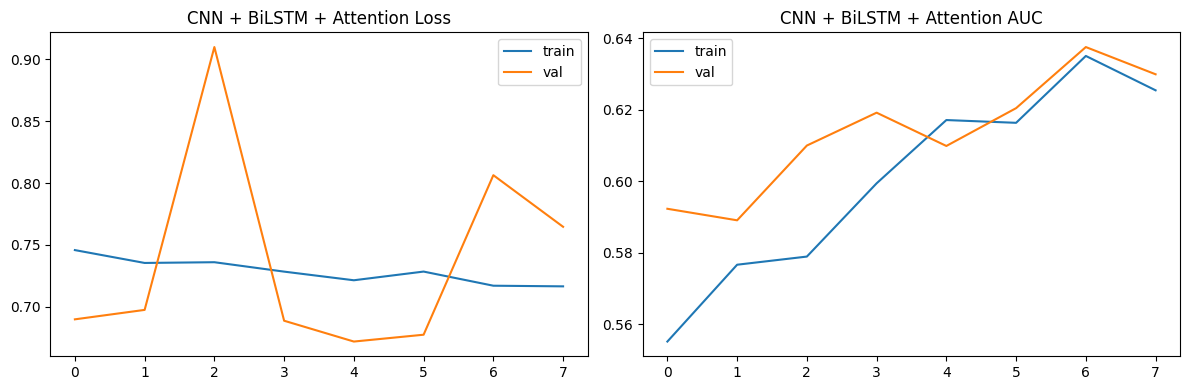

CNN + BiLSTM AUC: 0.6048999007769027
CNN + BiLSTM Best Threshold: 0.15000000000000002
CNN + BiLSTM Best F1: 0.4717870282336406
              precision    recall  f1-score   support

           0      0.855     0.264     0.403     32724
           1      0.322     0.886     0.472     12883

    accuracy                          0.440     45607
   macro avg      0.588     0.575     0.438     45607
weighted avg      0.704     0.440     0.423     45607



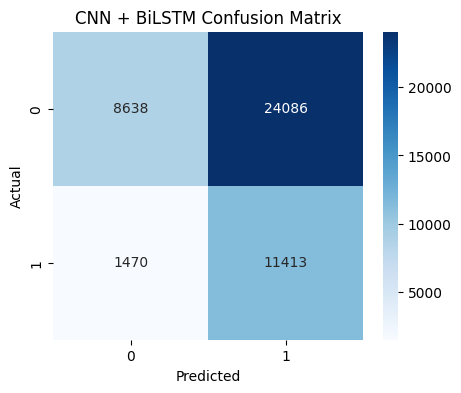

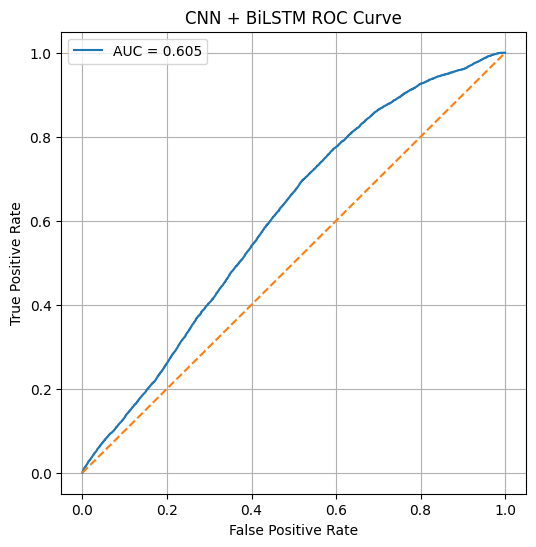

In [ ]:
plot_history(bilstm_history, "CNN + BiLSTM + Attention")

bilstm_results = evaluate_model(bilstm_model, test_seq)

print("CNN + BiLSTM AUC:", bilstm_results["auc"])
print("CNN + BiLSTM Best Threshold:", bilstm_results["best_thr"])
print("CNN + BiLSTM Best F1:", bilstm_results["best_f1"])
print(bilstm_results["report"])

plot_cm(bilstm_results["cm"], "CNN + BiLSTM Confusion Matrix")
plot_roc(bilstm_results["y_true"], bilstm_results["y_prob"], "CNN + BiLSTM ROC Curve")

In [ ]:
from sklearn.metrics import (
    roc_auc_score, f1_score, confusion_matrix,
    classification_report, roc_curve,
    precision_score, recall_score
)

def evaluate_model(model, test_seq):
    y_true, y_prob = [], []

    for i in range(len(test_seq)):
        xb, yb = test_seq[i]
        pb = model.predict(xb, verbose=0).ravel()
        y_true.append(yb)
        y_prob.append(pb)

    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)

    auc_score = roc_auc_score(y_true, y_prob)

    best_thr = 0.5
    best_f1 = -1

    for t in np.arange(0.05, 0.95, 0.05):
        pred = (y_prob >= t).astype(int)
        f1 = f1_score(y_true, pred)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = t

    pred_best = (y_prob >= best_thr).astype(int)

    precision = precision_score(y_true, pred_best, zero_division=0)
    recall = recall_score(y_true, pred_best, zero_division=0)

    cm = confusion_matrix(y_true, pred_best)
    report = classification_report(y_true, pred_best, digits=3)

    return {
        "y_true": y_true,
        "y_prob": y_prob,
        "auc": auc_score,
        "best_thr": best_thr,
        "best_f1": best_f1,
        "precision": precision,
        "recall": recall,
        "cm": cm,
        "report": report
    }

# COMPARISON GRAPHS

In [ ]:
comparison_df = pd.DataFrame([
    ["CNN", cnn_results["auc"], cnn_results["best_thr"], cnn_results["best_f1"]],

    ["CNN + BiLSTM", bilstm_results["auc"], bilstm_results["best_thr"], bilstm_results["best_f1"]],

    ["CNN + Transformer", trans_results["auc"], trans_results["best_thr"], trans_results["best_f1"]],

    ["VGG16", vgg_results["auc"], vgg_results["best_thr"], vgg_results["best_f1"]],

    ["EfficientNet", eff_results["auc"], eff_results["best_thr"], eff_results["best_f1"]],

], columns=["Model", "AUC", "Best Threshold", "Best F1"])

comparison_df

,Model,AUC,Best Threshold,Best F1
0,CNN,0.607725,0.55,0.475030
1,CNN + BiLSTM,0.604900,0.15,0.471787
2,CNN + Transformer,0.590444,0.60,0.456623
3,VGG16,0.597345,0.50,0.465029
4,EfficientNet,0.507110,0.05,0.440520


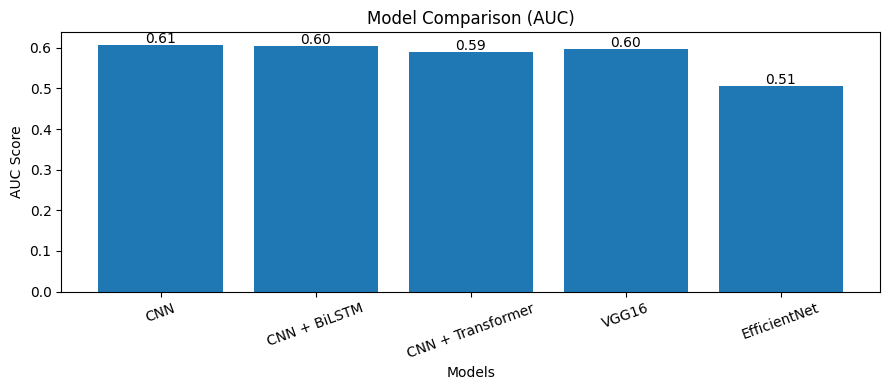

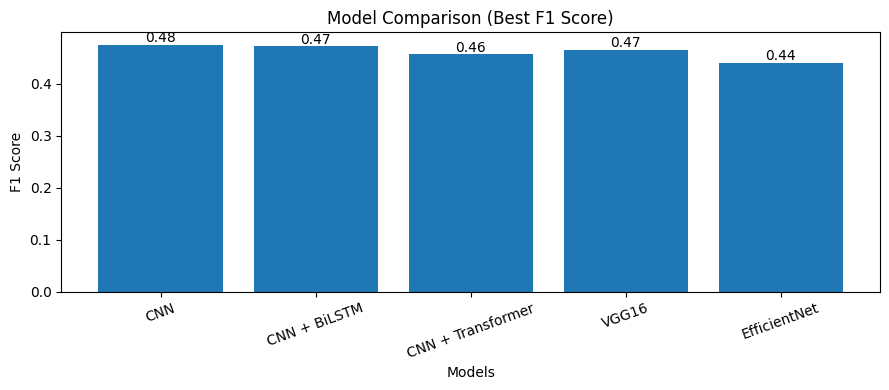

In [ ]:
# AUC Comparison
plt.figure(figsize=(9,4))
plt.bar(comparison_df["Model"], comparison_df["AUC"])
plt.title("Model Comparison (AUC)")
plt.ylabel("AUC Score")
plt.xlabel("Models")
plt.xticks(rotation=20)

# adding values on top of bars
for i, v in enumerate(comparison_df["AUC"]):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()


# F1 Comparison
plt.figure(figsize=(9,4))
plt.bar(comparison_df["Model"], comparison_df["Best F1"])
plt.title("Model Comparison (Best F1 Score)")
plt.ylabel("F1 Score")
plt.xlabel("Models")
plt.xticks(rotation=20)

# adding values on top
for i, v in enumerate(comparison_df["Best F1"]):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.tight_layout()
plt.show()

## Conclusion

The results show that detecting apnea from snore-based spectrograms is challenging due to subtle differences, but deep learning models can capture useful patterns for classification.